In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [15]:
df = pd.read_csv(
    "../data/processed/upi_transactions_processed.csv",
    parse_dates=["timestamp"]
)

In [16]:
print("=" * 60)
print("UPI TRANSACTION INTELLIGENCE PLATFORM")
print("Exploratory Data Analysis")
print("=" * 60)

print(f"Rows               : {df.shape[0]:,}")
print(f"Columns            : {df.shape[1]}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Duplicate Records  : {df.duplicated().sum()}")

UPI TRANSACTION INTELLIGENCE PLATFORM
Exploratory Data Analysis
Rows               : 250,000
Columns            : 17
Missing Values     : 0
Duplicate Records  : 0


In [17]:
df.dtypes

transaction_id                object
timestamp             datetime64[ns]
transaction_type              object
merchant_category             object
amount_inr                     int64
transaction_status            object
sender_age_group              object
receiver_age_group            object
sender_state                  object
sender_bank                   object
receiver_bank                 object
device_type                   object
network_type                  object
fraud_flag                     int64
hour_of_day                    int64
day_of_week                   object
is_weekend                     int64
dtype: object

In [18]:
df.head()

,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [20]:
## 6.2.1 Transaction Type Distribution

### Business Question
# Which transaction type is most frequently used in the dataset?

### Objective
# To analyze the frequency and percentage distribution of UPI transaction types.

In [ ]:
## Frequency Distribution of Transaction Types
transaction_type = (
    df["transaction_type"]
      .value_counts()
      .reset_index()
)

transaction_type.columns = [
    "Transaction Type",
    "Transaction Count"
]

transaction_type

,Transaction Type,Transaction Count
0,P2P,112445
1,P2M,87660
2,Bill Payment,37368
3,Recharge,12527


In [ ]:
## Percentage Distribution of Transaction Types
transaction_type["Percentage"] = (
    transaction_type["Transaction Count"]
    / transaction_type["Transaction Count"].sum()
    * 100
).round(2)

transaction_type

,Transaction Type,Transaction Count,Percentage
0,P2P,112445,44.98
1,P2M,87660,35.06
2,Bill Payment,37368,14.95
3,Recharge,12527,5.01


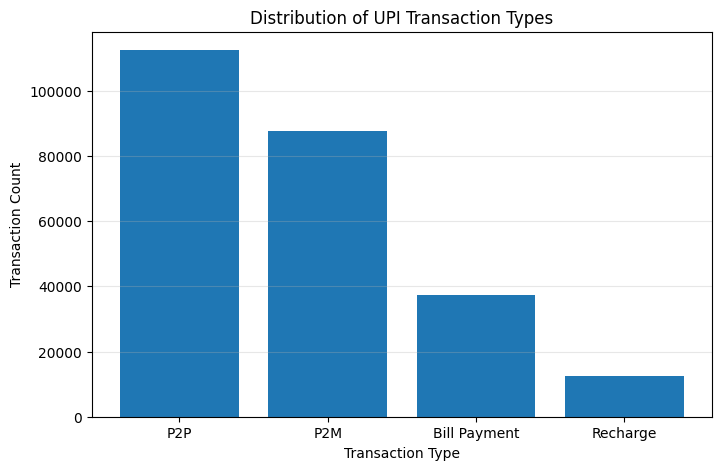

In [ ]:
## Bar Chart Visualization 
plt.figure(figsize=(8,5))

plt.bar(
    transaction_type["Transaction Type"],
    transaction_type["Transaction Count"]
)

plt.title("Distribution of UPI Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Count")

plt.grid(axis="y", alpha=0.3)

plt.show()

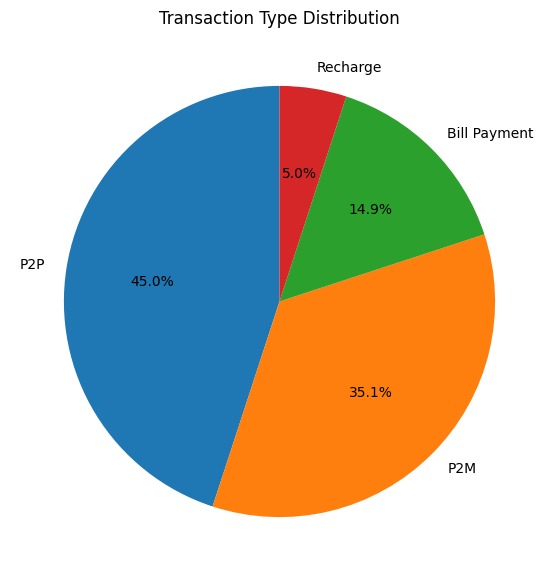

In [ ]:
## Pie Chart Visualization
plt.figure(figsize=(7,7))

plt.pie(
    transaction_type["Transaction Count"],
    labels=transaction_type["Transaction Type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Transaction Type Distribution")

plt.show()

In [ ]:
## Most Frequently Used Transaction Type
transaction_type.iloc[0]

Transaction Type        P2P
Transaction Count    112445
Percentage            44.98
Name: 0, dtype: object

In [ ]:
## 6.2.2 Merchant Category Distribution

### Business Question
# Which merchant categories receive the highest number of UPI transactions?

### Objective
# To analyze the distribution of merchant categories and identify the categories with the highest transaction volume.

In [26]:
merchant_category = (
    df["merchant_category"]
    .value_counts()
    .reset_index()
)

merchant_category.columns = [
    "Merchant Category",
    "Transaction Count"
]

merchant_category

,Merchant Category,Transaction Count
0,Grocery,49966
1,Food,37464
2,Shopping,29872
3,Fuel,25063
4,Other,24828
5,Utilities,22338
6,Transport,20105
7,Entertainment,20103
8,Healthcare,12663
9,Education,7598


In [27]:
merchant_category["Percentage"] = (
    merchant_category["Transaction Count"]
    / merchant_category["Transaction Count"].sum()
    * 100
).round(2)

merchant_category

,Merchant Category,Transaction Count,Percentage
0,Grocery,49966,19.99
1,Food,37464,14.99
2,Shopping,29872,11.95
3,Fuel,25063,10.03
4,Other,24828,9.93
5,Utilities,22338,8.94
6,Transport,20105,8.04
7,Entertainment,20103,8.04
8,Healthcare,12663,5.07
9,Education,7598,3.04


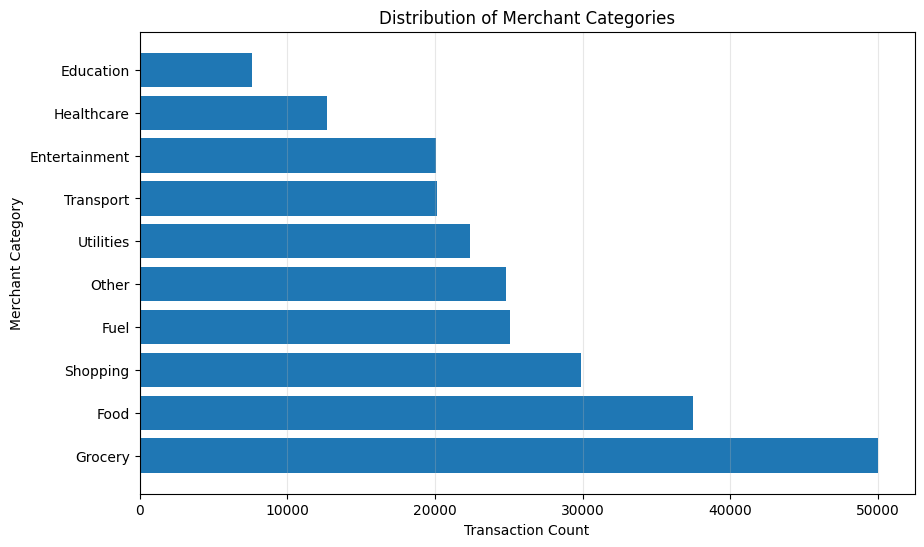

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    merchant_category["Merchant Category"],
    merchant_category["Transaction Count"]
)

plt.title("Distribution of Merchant Categories")
plt.xlabel("Transaction Count")
plt.ylabel("Merchant Category")

plt.grid(axis="x", alpha=0.3)

plt.show()

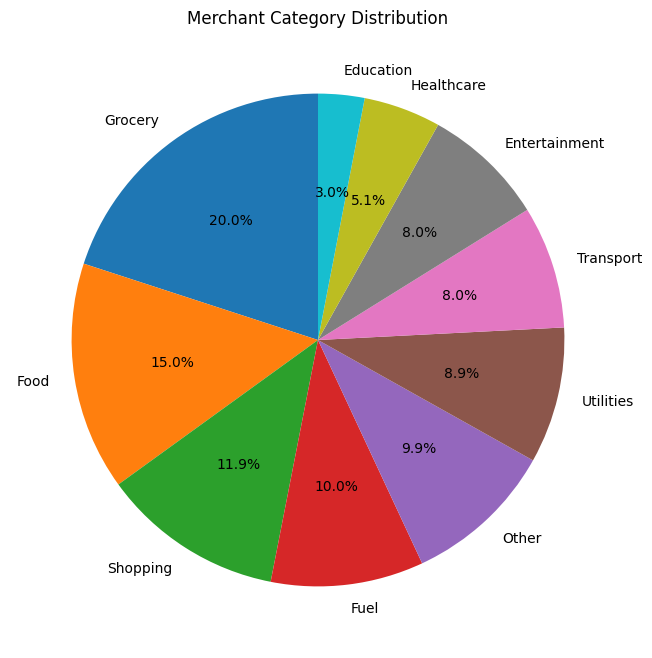

In [29]:
plt.figure(figsize=(8,8))

plt.pie(
    merchant_category["Transaction Count"],
    labels=merchant_category["Merchant Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Merchant Category Distribution")

plt.show()

In [30]:
merchant_category.iloc[0]

Merchant Category    Grocery
Transaction Count      49966
Percentage             19.99
Name: 0, dtype: object

In [ ]:
## 6.2.3 Transaction Status Distribution

### Business Question

# What proportion of UPI transactions are successful and failed?

### Objective

# To measure transaction outcomes and establish the dataset’s overall transaction success and failure rates.

In [31]:
status_distribution = (
    df["transaction_status"]
    .value_counts()
    .rename_axis("Transaction Status")
    .reset_index(name="Transaction Count")
)

status_distribution["Percentage"] = (
    status_distribution["Transaction Count"]
    .div(status_distribution["Transaction Count"].sum())
    .mul(100)
    .round(2)
)

status_distribution

,Transaction Status,Transaction Count,Percentage
0,SUCCESS,237624,95.05
1,FAILED,12376,4.95


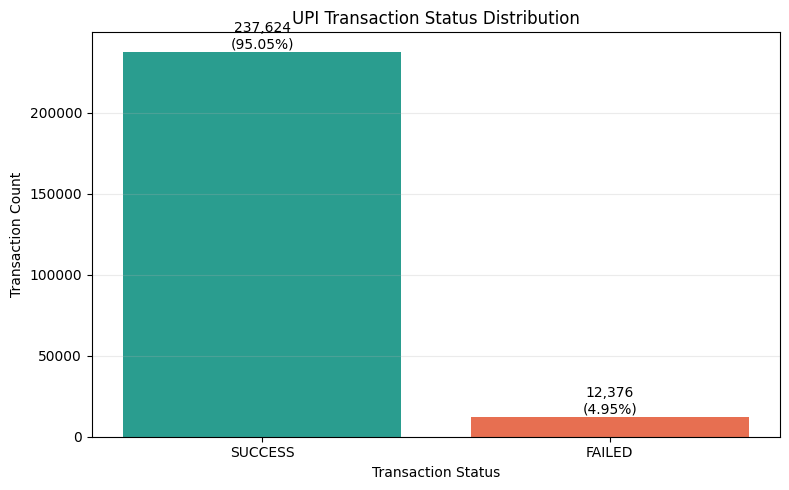

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    status_distribution["Transaction Status"],
    status_distribution["Transaction Count"],
    color=["#2A9D8F", "#E76F51"]
)

ax.set_title("UPI Transaction Status Distribution")
ax.set_xlabel("Transaction Status")
ax.set_ylabel("Transaction Count")
ax.grid(axis="y", alpha=0.25)

for bar, count, percentage in zip(
    bars,
    status_distribution["Transaction Count"],
    status_distribution["Percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [33]:
total_transactions = len(df)

successful_transactions = (
    df["transaction_status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("success")
    .sum()
)

failed_transactions = total_transactions - successful_transactions

success_rate = successful_transactions / total_transactions * 100
failure_rate = failed_transactions / total_transactions * 100

print(f"Total transactions      : {total_transactions:,}")
print(f"Successful transactions : {successful_transactions:,}")
print(f"Failed transactions     : {failed_transactions:,}")
print(f"Success rate            : {success_rate:.2f}%")
print(f"Failure rate            : {failure_rate:.2f}%")

Total transactions      : 250,000
Successful transactions : 237,624
Failed transactions     : 12,376
Success rate            : 95.05%
Failure rate            : 4.95%


In [ ]:
## 6.2.4 Transaction Amount Distribution

### Business Question

# How are UPI transaction amounts distributed, and are there unusually high-value transactions?

### Objective

# To examine the central tendency, spread, skewness, and potential outliers in transaction amounts.

In [34]:
amount_summary = df["amount_inr"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

amount_summary

count    250000.000000
mean       1311.756036
std        1848.059224
min          10.000000
25%         288.000000
50%         629.000000
75%        1596.000000
90%        3236.000000
95%        4687.050000
99%        9003.010000
max       42099.000000
Name: amount_inr, dtype: float64

In [35]:
amount_statistics = pd.Series({
    "Mean": df["amount_inr"].mean(),
    "Median": df["amount_inr"].median(),
    "Mode": df["amount_inr"].mode().iloc[0],
    "Minimum": df["amount_inr"].min(),
    "Maximum": df["amount_inr"].max(),
    "Standard Deviation": df["amount_inr"].std(),
    "Skewness": df["amount_inr"].skew()
}).round(2)

amount_statistics

Mean                   1311.76
Median                  629.00
Mode                    215.00
Minimum                  10.00
Maximum               42099.00
Standard Deviation     1848.06
Skewness                  3.92
dtype: float64

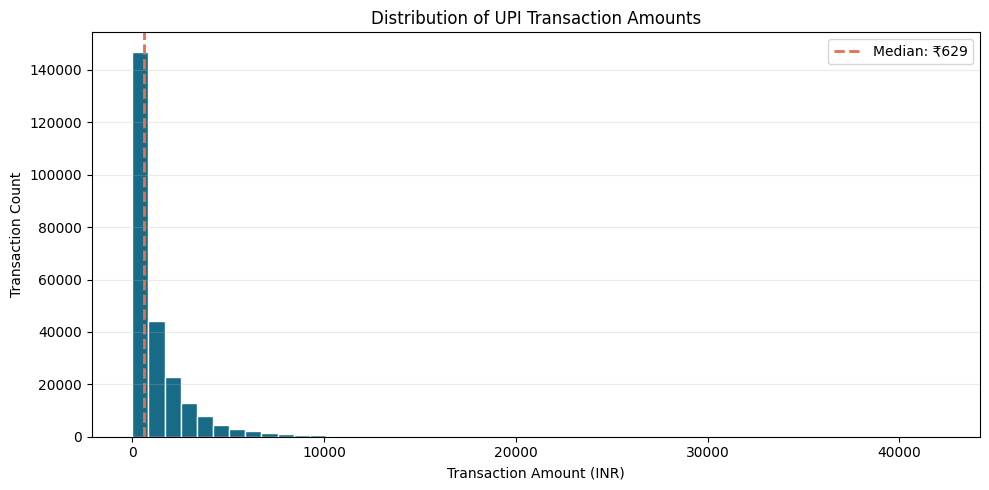

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["amount_inr"],
    bins=50,
    color="#176B87",
    edgecolor="white"
)

ax.axvline(
    df["amount_inr"].median(),
    color="#E76F51",
    linestyle="--",
    linewidth=2,
    label=f'Median: ₹{df["amount_inr"].median():,.0f}'
)

ax.set_title("Distribution of UPI Transaction Amounts")
ax.set_xlabel("Transaction Amount (INR)")
ax.set_ylabel("Transaction Count")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [37]:
q1 = df["amount_inr"].quantile(0.25)
q3 = df["amount_inr"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

potential_outliers = df[
    (df["amount_inr"] < lower_bound) |
    (df["amount_inr"] > upper_bound)
]

print(f"Q1                  : ₹{q1:,.2f}")
print(f"Q3                  : ₹{q3:,.2f}")
print(f"IQR                 : ₹{iqr:,.2f}")
print(f"Lower bound         : ₹{lower_bound:,.2f}")
print(f"Upper bound         : ₹{upper_bound:,.2f}")
print(f"Potential outliers  : {len(potential_outliers):,}")
print(
    f"Outlier percentage  : "
    f"{len(potential_outliers) / len(df) * 100:.2f}%"
)

Q1                  : ₹288.00
Q3                  : ₹1,596.00
IQR                 : ₹1,308.00
Lower bound         : ₹-1,674.00
Upper bound         : ₹3,558.00
Potential outliers  : 21,171
Outlier percentage  : 8.47%


In [ ]:
## 6.2.5 Sender Bank Distribution

### Business Question

# Which sender banks process the highest number and value of UPI transactions?

### Objective

# To compare sender banks by transaction count, transaction value, and share of total transaction volume.

In [38]:
## Analysis table
sender_bank_summary = (
    df.groupby("sender_bank")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount_inr", "sum"),
        average_transaction_value=("amount_inr", "mean")
    )
    .reset_index()
)

sender_bank_summary["transaction_share_percentage"] = (
    sender_bank_summary["transaction_count"]
    .div(sender_bank_summary["transaction_count"].sum())
    .mul(100)
    .round(2)
)

sender_bank_summary["average_transaction_value"] = (
    sender_bank_summary["average_transaction_value"].round(2)
)

sender_bank_summary = sender_bank_summary.sort_values(
    "transaction_count",
    ascending=False
)

sender_bank_summary

,sender_bank,transaction_count,total_transaction_value,average_transaction_value,transaction_share_percentage
6,SBI,62693,82816520,1320.99,25.08
1,HDFC,37485,49791194,1328.30,14.99
2,ICICI,29769,38731193,1301.06,11.91
3,IndusInd,25173,32842711,1304.68,10.07
0,Axis,25042,32472530,1296.72,10.02
5,PNB,24946,32476972,1301.89,9.98
7,Yes Bank,24860,32492477,1307.02,9.94
4,Kotak,20032,26315412,1313.67,8.01


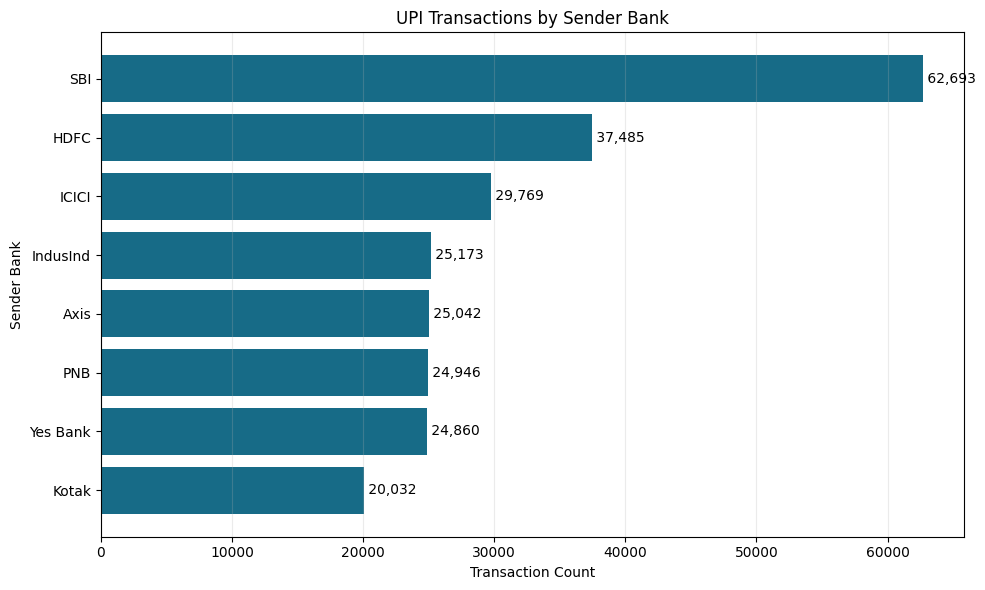

In [39]:
## Labeled bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    sender_bank_summary["sender_bank"],
    sender_bank_summary["transaction_count"],
    color="#176B87"
)

ax.invert_yaxis()
ax.set_title("UPI Transactions by Sender Bank")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("Sender Bank")
ax.grid(axis="x", alpha=0.25)

for bar, count in zip(
    bars,
    sender_bank_summary["transaction_count"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 6.2.6 Receiver Bank Distribution
### Business Question
## Which receiver banks receive the highest number and value of UPI transactions?
### Objective
## To compare receiver banks based on transaction count, transaction share, total received value, and average received transaction value.

In [40]:
## Create the receiver-bank summary
receiver_bank_summary = (
    df.groupby("receiver_bank")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount_inr", "sum"),
        average_transaction_value=("amount_inr", "mean")
    )
    .reset_index()
)

receiver_bank_summary["transaction_share_percentage"] = (
    receiver_bank_summary["transaction_count"]
    .div(receiver_bank_summary["transaction_count"].sum())
    .mul(100)
    .round(2)
)

receiver_bank_summary["average_transaction_value"] = (
    receiver_bank_summary["average_transaction_value"].round(2)
)

receiver_bank_summary = receiver_bank_summary.sort_values(
    "transaction_count",
    ascending=False
)

receiver_bank_summary

,receiver_bank,transaction_count,total_transaction_value,average_transaction_value,transaction_share_percentage
6,SBI,62378,82565386,1323.63,24.95
1,HDFC,37651,49157476,1305.61,15.06
2,ICICI,29944,39029938,1303.43,11.98
3,IndusInd,25086,32677495,1302.62,10.03
7,Yes Bank,25009,32838599,1313.07,10.00
0,Axis,24992,33007678,1320.73,10.00
5,PNB,24802,32160203,1296.68,9.92
4,Kotak,20138,26502234,1316.03,8.06


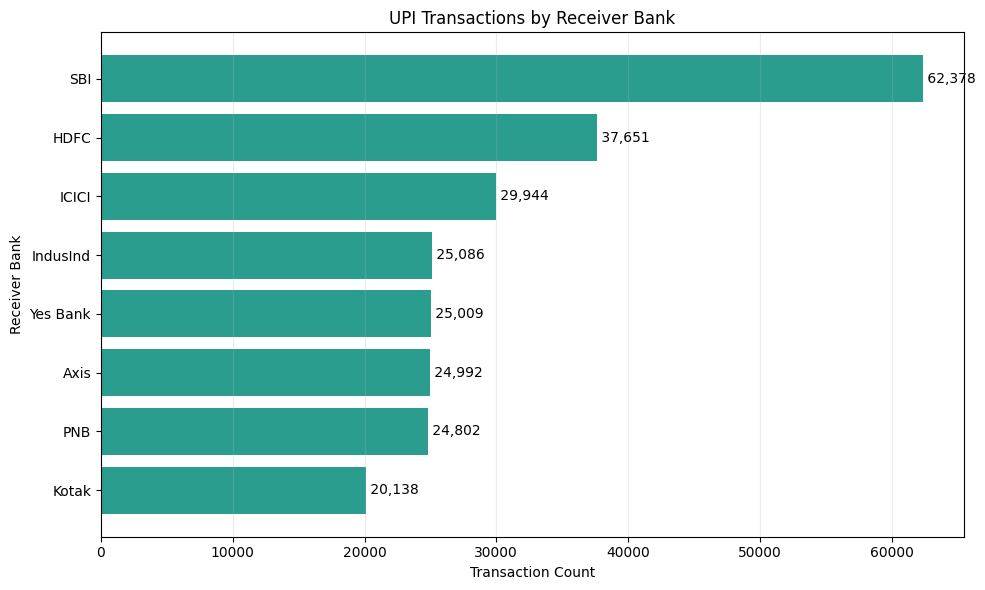

In [41]:
## Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    receiver_bank_summary["receiver_bank"],
    receiver_bank_summary["transaction_count"],
    color="#2A9D8F"
)

ax.invert_yaxis()
ax.set_title("UPI Transactions by Receiver Bank")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("Receiver Bank")
ax.grid(axis="x", alpha=0.25)

for bar, count in zip(
    bars,
    receiver_bank_summary["transaction_count"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 6.2.7 Sender State Distribution
### Business Question
# Which states generate the highest number and value of UPI transactions?
### Objective
# To compare sender states based on transaction count, transaction share, total transaction value, and average transaction value.

In [42]:
## Create the state summary
sender_state_summary = (
    df.groupby("sender_state")
    .agg(
        transaction_count=("transaction_id", "count"),
        total_transaction_value=("amount_inr", "sum"),
        average_transaction_value=("amount_inr", "mean")
    )
    .reset_index()
)

sender_state_summary["transaction_share_percentage"] = (
    sender_state_summary["transaction_count"]
    .div(sender_state_summary["transaction_count"].sum())
    .mul(100)
    .round(2)
)

sender_state_summary["average_transaction_value"] = (
    sender_state_summary["average_transaction_value"].round(2)
)

sender_state_summary = sender_state_summary.sort_values(
    "transaction_count",
    ascending=False
)

sender_state_summary

,sender_state,transaction_count,total_transaction_value,average_transaction_value,transaction_share_percentage
4,Maharashtra,37427,49043948,1310.39,14.97
8,Uttar Pradesh,30125,40035717,1328.99,12.05
3,Karnataka,29756,38451158,1292.22,11.90
6,Tamil Nadu,25367,33343518,1314.44,10.15
1,Delhi,24870,32689865,1314.43,9.95
7,Telangana,22435,29750930,1326.09,8.97
2,Gujarat,20061,25988190,1295.46,8.02
0,Andhra Pradesh,20006,25952619,1297.24,8.00
5,Rajasthan,19981,26730470,1337.79,7.99
9,West Bengal,19972,25952594,1299.45,7.99


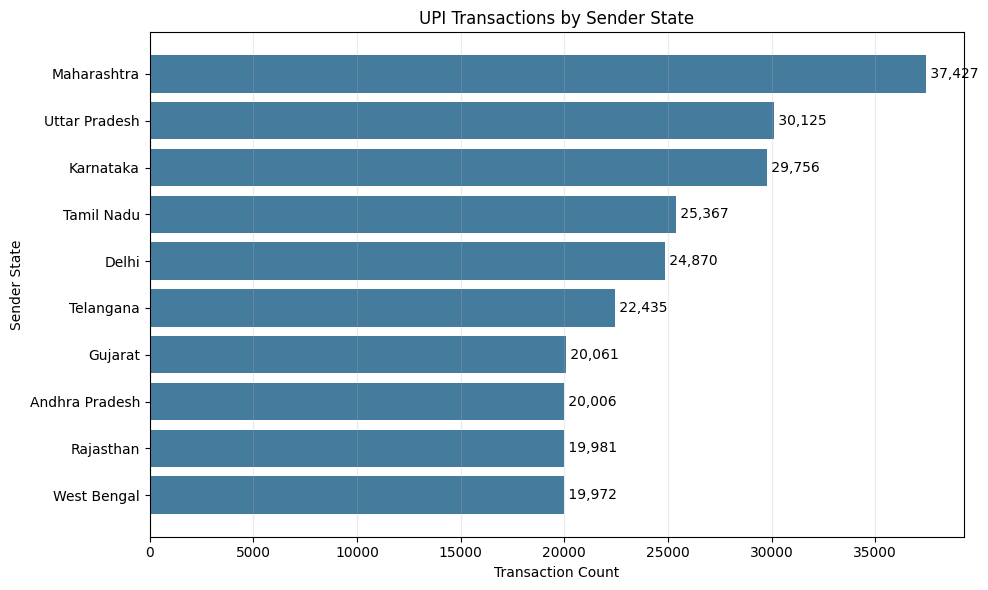

In [43]:
## Create the chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    sender_state_summary["sender_state"],
    sender_state_summary["transaction_count"],
    color="#457B9D"
)

ax.invert_yaxis()
ax.set_title("UPI Transactions by Sender State")
ax.set_xlabel("Transaction Count")
ax.set_ylabel("Sender State")
ax.grid(axis="x", alpha=0.25)

for bar, count in zip(
    bars,
    sender_state_summary["transaction_count"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 6.2.8 Device Type Distribution
### Business Question
# Which device types are most commonly used for UPI transactions?
### Objective
# To measure the distribution of transactions across device types and identify the primary transaction channel.

In [44]:
## Create the summary table
device_summary = (
    df["device_type"]
    .value_counts()
    .rename_axis("device_type")
    .reset_index(name="transaction_count")
)

device_summary["transaction_share_percentage"] = (
    device_summary["transaction_count"]
    .div(device_summary["transaction_count"].sum())
    .mul(100)
    .round(2)
)

device_summary

,device_type,transaction_count,transaction_share_percentage
0,Android,187777,75.11
1,iOS,49613,19.85
2,Web,12610,5.04


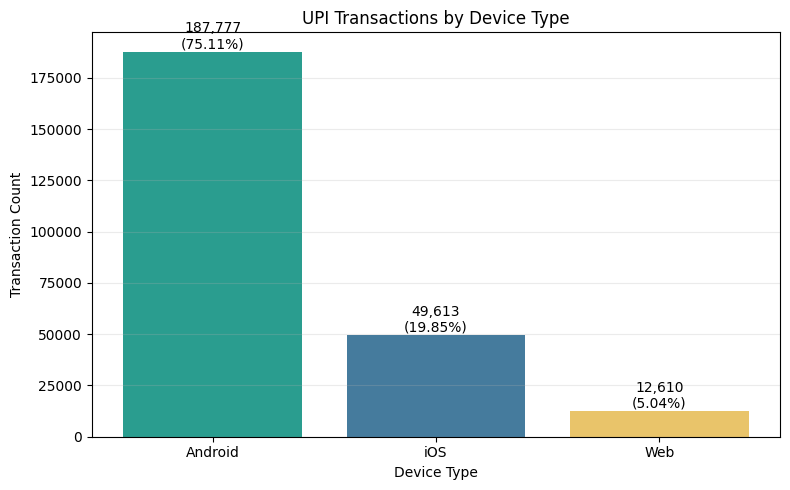

In [45]:
## Create the chart
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    device_summary["device_type"],
    device_summary["transaction_count"],
    color=["#2A9D8F", "#457B9D", "#E9C46A"]
)

ax.set_title("UPI Transactions by Device Type")
ax.set_xlabel("Device Type")
ax.set_ylabel("Transaction Count")
ax.grid(axis="y", alpha=0.25)

for bar, count, percentage in zip(
    bars,
    device_summary["transaction_count"],
    device_summary["transaction_share_percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 6.2.9 Network Type Distribution
### Business Question
## Which network types are most frequently used for UPI transactions?
### Objective
## To analyze transaction distribution across network types and understand the connectivity channels supporting UPI activity.

In [46]:
## Create the summary table
network_summary = (
    df["network_type"]
    .value_counts()
    .rename_axis("network_type")
    .reset_index(name="transaction_count")
)

network_summary["transaction_share_percentage"] = (
    network_summary["transaction_count"]
    .div(network_summary["transaction_count"].sum())
    .mul(100)
    .round(2)
)

network_summary

,network_type,transaction_count,transaction_share_percentage
0,4G,149813,59.93
1,5G,62582,25.03
2,WiFi,25134,10.05
3,3G,12471,4.99


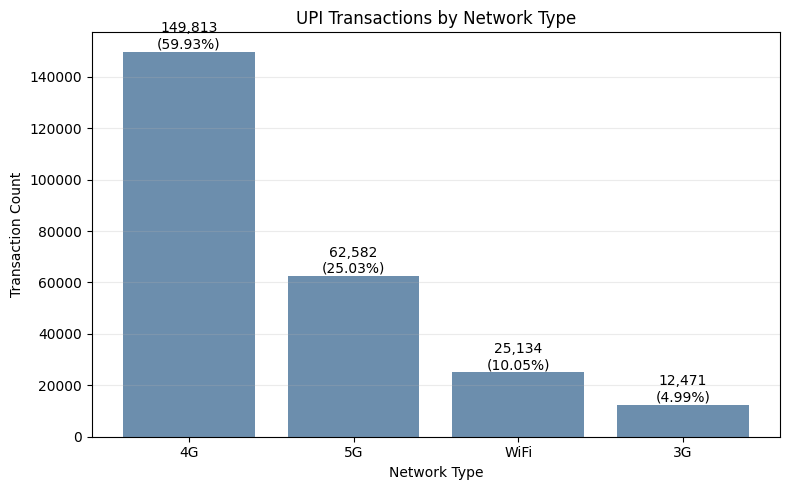

In [47]:
## Create the chart
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    network_summary["network_type"],
    network_summary["transaction_count"],
    color="#6C8EAD"
)

ax.set_title("UPI Transactions by Network Type")
ax.set_xlabel("Network Type")
ax.set_ylabel("Transaction Count")
ax.grid(axis="y", alpha=0.25)

for bar, count, percentage in zip(
    bars,
    network_summary["transaction_count"],
    network_summary["transaction_share_percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 6.2.10 Fraud Flag Distribution
### Business Question
# What proportion of transactions are labelled as fraudulent?
### Objective
# To measure the distribution of normal and fraudulent transactions and determine the level of class imbalance in the fraud target.

In [48]:
# Create the distribution table
fraud_summary = (
    df["fraud_flag"]
    .value_counts()
    .sort_index()
    .rename_axis("fraud_flag")
    .reset_index(name="transaction_count")
)

fraud_summary["fraud_category"] = fraud_summary["fraud_flag"].map({
    0: "Normal",
    1: "Fraud"
})

fraud_summary["transaction_share_percentage"] = (
    fraud_summary["transaction_count"]
    .div(fraud_summary["transaction_count"].sum())
    .mul(100)
    .round(3)
)

fraud_summary = fraud_summary[
    [
        "fraud_flag",
        "fraud_category",
        "transaction_count",
        "transaction_share_percentage"
    ]
]

fraud_summary

,fraud_flag,fraud_category,transaction_count,transaction_share_percentage
0,0,Normal,249520,99.808
1,1,Fraud,480,0.192


In [49]:
# Calculate the imbalance
normal_count = (df["fraud_flag"] == 0).sum()
fraud_count = (df["fraud_flag"] == 1).sum()

fraud_rate = fraud_count / len(df) * 100
imbalance_ratio = normal_count / fraud_count

print(f"Normal transactions : {normal_count:,}")
print(f"Fraud transactions  : {fraud_count:,}")
print(f"Fraud rate          : {fraud_rate:.3f}%")
print(f"Imbalance ratio     : {imbalance_ratio:.2f}:1")

Normal transactions : 249,520
Fraud transactions  : 480
Fraud rate          : 0.192%
Imbalance ratio     : 519.83:1


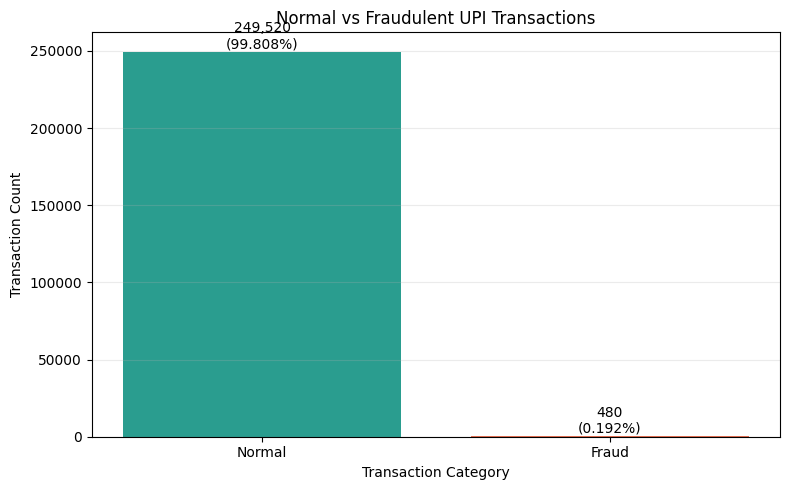

In [50]:
# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    fraud_summary["fraud_category"],
    fraud_summary["transaction_count"],
    color=["#2A9D8F", "#E76F51"]
)

ax.set_title("Normal vs Fraudulent UPI Transactions")
ax.set_xlabel("Transaction Category")
ax.set_ylabel("Transaction Count")
ax.grid(axis="y", alpha=0.25)

for bar, count, percentage in zip(
    bars,
    fraud_summary["transaction_count"],
    fraud_summary["transaction_share_percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.3f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

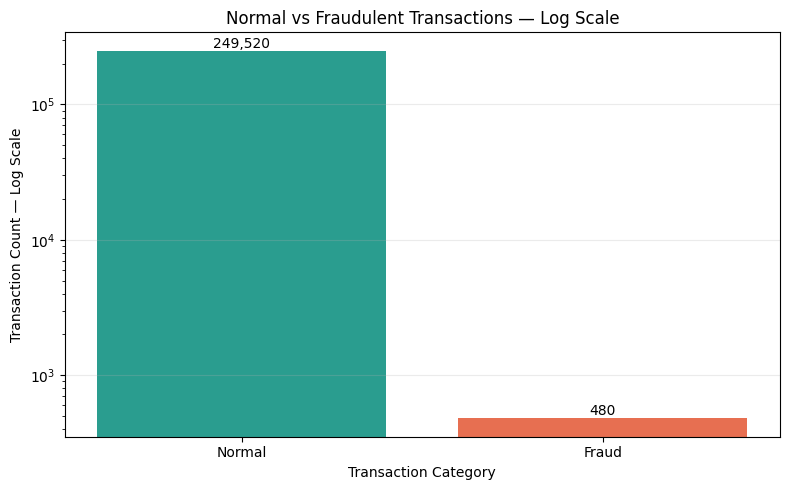

In [51]:
# Add a logarithmic chart
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    fraud_summary["fraud_category"],
    fraud_summary["transaction_count"],
    color=["#2A9D8F", "#E76F51"]
)

ax.set_yscale("log")
ax.set_title("Normal vs Fraudulent Transactions — Log Scale")
ax.set_xlabel("Transaction Category")
ax.set_ylabel("Transaction Count — Log Scale")
ax.grid(axis="y", alpha=0.25)

for bar, count in zip(
    bars,
    fraud_summary["transaction_count"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# 6.3 Failure-Focused Bivariate Analysis
## 6.3.1 Transaction Type vs Transaction Status
### Business Question
# Which transaction types have the highest number and rate of failed transactions?
### Objective
# To compare transaction outcomes across transaction types and identify segments with elevated failure rates.

In [52]:
# Create the performance table
transaction_type_status = (
    df.groupby("transaction_type")
    .agg(
        total_transactions=("transaction_id", "count"),
        successful_transactions=(
            "transaction_status",
            lambda values: values.astype(str)
            .str.strip()
            .str.upper()
            .eq("SUCCESS")
            .sum()
        ),
        failed_transactions=(
            "transaction_status",
            lambda values: values.astype(str)
            .str.strip()
            .str.upper()
            .eq("FAILED")
            .sum()
        )
    )
    .reset_index()
)

transaction_type_status["success_rate_percentage"] = (
    transaction_type_status["successful_transactions"]
    .div(transaction_type_status["total_transactions"])
    .mul(100)
    .round(2)
)

transaction_type_status["failure_rate_percentage"] = (
    transaction_type_status["failed_transactions"]
    .div(transaction_type_status["total_transactions"])
    .mul(100)
    .round(2)
)

transaction_type_status = transaction_type_status.sort_values(
    "failure_rate_percentage",
    ascending=False
)

transaction_type_status

,transaction_type,total_transactions,successful_transactions,failed_transactions,success_rate_percentage,failure_rate_percentage
3,Recharge,12527,11889,638,94.91,5.09
2,P2P,112445,106870,5575,95.04,4.96
1,P2M,87660,83321,4339,95.05,4.95
0,Bill Payment,37368,35544,1824,95.12,4.88


In [53]:
# Verify the totals
print(
    "Total transactions represented:",
    f"{transaction_type_status['total_transactions'].sum():,}"
)

print(
    "Total failures represented:",
    f"{transaction_type_status['failed_transactions'].sum():,}"
)

Total transactions represented: 250,000
Total failures represented: 12,376


In [54]:
# Calculate the overall baseline
overall_failure_rate = (
    df["transaction_status"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("FAILED")
    .mean()
    * 100
)

print(f"Overall failure rate: {overall_failure_rate:.2f}%")

Overall failure rate: 4.95%


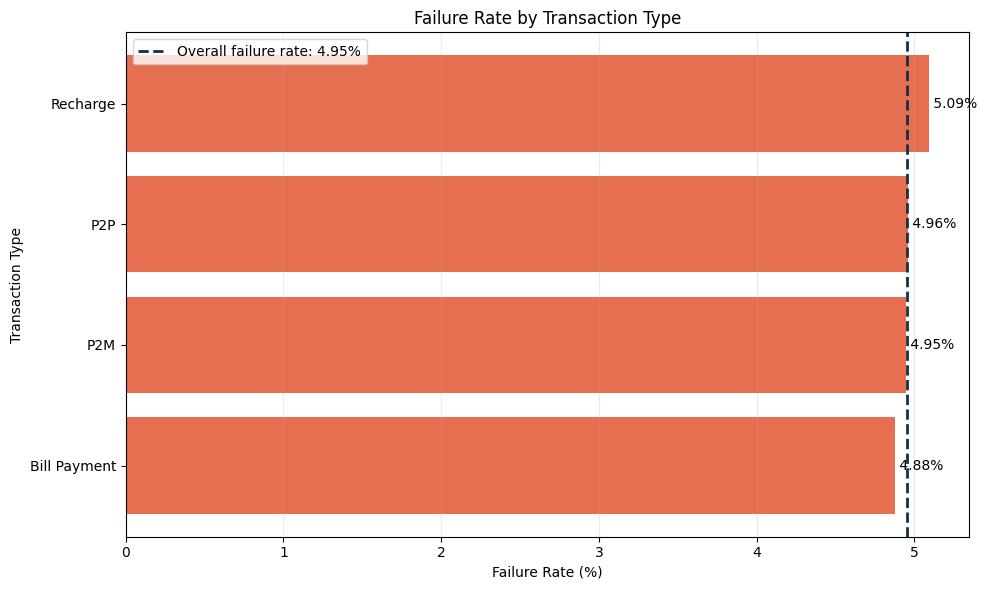

In [55]:
# Create the failure-rate chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    transaction_type_status["transaction_type"],
    transaction_type_status["failure_rate_percentage"],
    color="#E76F51"
)

ax.invert_yaxis()

ax.axvline(
    overall_failure_rate,
    color="#12304A",
    linestyle="--",
    linewidth=2,
    label=f"Overall failure rate: {overall_failure_rate:.2f}%"
)

ax.set_title("Failure Rate by Transaction Type")
ax.set_xlabel("Failure Rate (%)")
ax.set_ylabel("Transaction Type")
ax.grid(axis="x", alpha=0.25)
ax.legend()

for bar, rate in zip(
    bars,
    transaction_type_status["failure_rate_percentage"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {rate:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

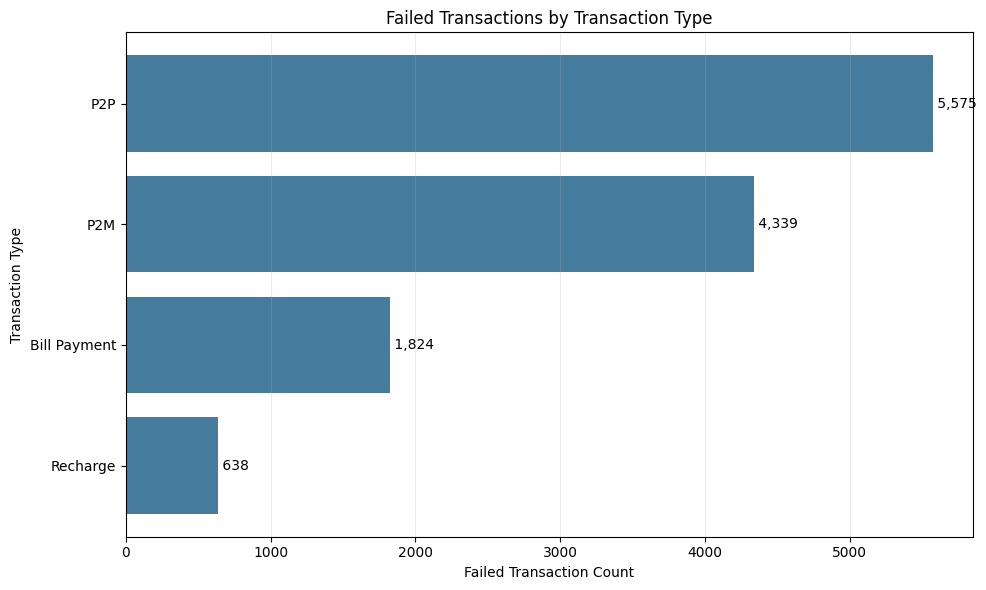

In [56]:
# Create the failed-transaction count chart
failed_count_order = transaction_type_status.sort_values(
    "failed_transactions",
    ascending=False
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    failed_count_order["transaction_type"],
    failed_count_order["failed_transactions"],
    color="#457B9D"
)

ax.invert_yaxis()
ax.set_title("Failed Transactions by Transaction Type")
ax.set_xlabel("Failed Transaction Count")
ax.set_ylabel("Transaction Type")
ax.grid(axis="x", alpha=0.25)

for bar, count in zip(
    bars,
    failed_count_order["failed_transactions"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [57]:
# Reusable status-summary function
def build_status_summary(data, group_column):
    status = (
        data["transaction_status"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    working_data = data.assign(
        _is_success=status.eq("SUCCESS"),
        _is_failure=status.eq("FAILED")
    )

    summary = (
        working_data.groupby(group_column)
        .agg(
            total_transactions=("transaction_id", "count"),
            successful_transactions=("_is_success", "sum"),
            failed_transactions=("_is_failure", "sum")
        )
        .reset_index()
    )

    summary["success_rate_percentage"] = (
        summary["successful_transactions"]
        .div(summary["total_transactions"])
        .mul(100)
        .round(2)
    )

    summary["failure_rate_percentage"] = (
        summary["failed_transactions"]
        .div(summary["total_transactions"])
        .mul(100)
        .round(2)
    )

    return summary.sort_values(
        "failure_rate_percentage",
        ascending=False
    )

In [ ]:
## 6.3.2 Merchant Category vs Transaction Status
### Business Question
# Which merchant categories have the highest number and rate of failed transactions?
### Objective
# To compare transaction outcomes across merchant categories and identify categories with elevated failure rates or operational impact.

In [58]:
# Generate the summary
merchant_status_summary = build_status_summary(
    df,
    "merchant_category"
)

merchant_status_summary

,merchant_category,total_transactions,successful_transactions,failed_transactions,success_rate_percentage,failure_rate_percentage
0,Education,7598,7199,399,94.75,5.25
7,Shopping,29872,28353,1519,94.91,5.09
4,Grocery,49966,47463,2503,94.99,5.01
2,Food,37464,35588,1876,94.99,5.01
6,Other,24828,23598,1230,95.05,4.95
1,Entertainment,20103,19113,990,95.08,4.92
9,Utilities,22338,21252,1086,95.14,4.86
5,Healthcare,12663,12051,612,95.17,4.83
3,Fuel,25063,23859,1204,95.20,4.80
8,Transport,20105,19148,957,95.24,4.76


In [59]:
# Verify totals
print(
    "Total transactions represented:",
    f"{merchant_status_summary['total_transactions'].sum():,}"
)

print(
    "Total failures represented:",
    f"{merchant_status_summary['failed_transactions'].sum():,}"
)

Total transactions represented: 250,000
Total failures represented: 12,376


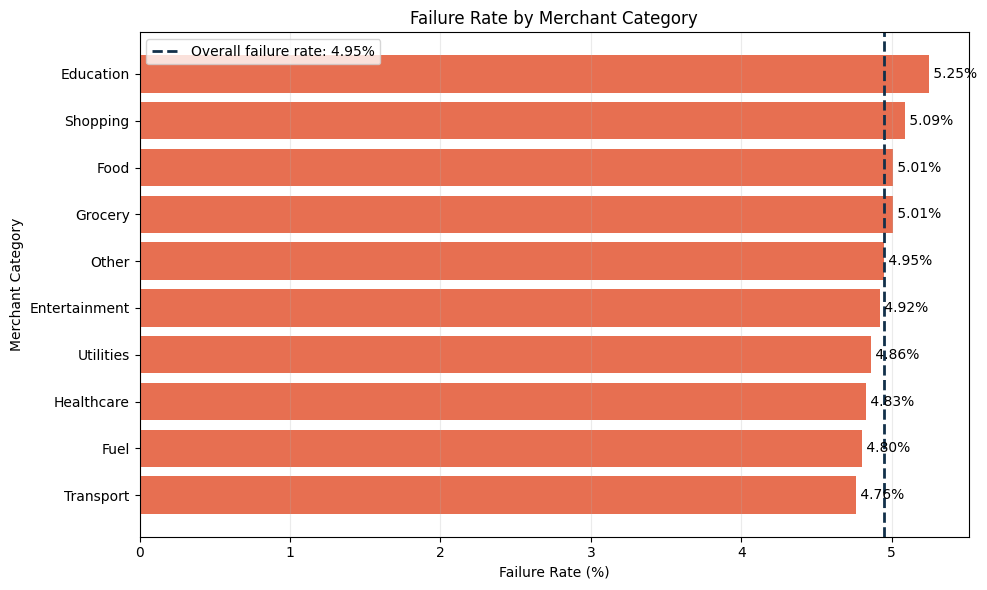

In [60]:
# Plot failure rates
fig, ax = plt.subplots(figsize=(10, 6))

rate_order = merchant_status_summary.sort_values(
    "failure_rate_percentage",
    ascending=True
)

bars = ax.barh(
    rate_order["merchant_category"],
    rate_order["failure_rate_percentage"],
    color="#E76F51"
)

ax.axvline(
    overall_failure_rate,
    color="#12304A",
    linestyle="--",
    linewidth=2,
    label=f"Overall failure rate: {overall_failure_rate:.2f}%"
)

ax.set_title("Failure Rate by Merchant Category")
ax.set_xlabel("Failure Rate (%)")
ax.set_ylabel("Merchant Category")
ax.grid(axis="x", alpha=0.25)
ax.legend()

for bar, rate in zip(
    bars,
    rate_order["failure_rate_percentage"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {rate:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

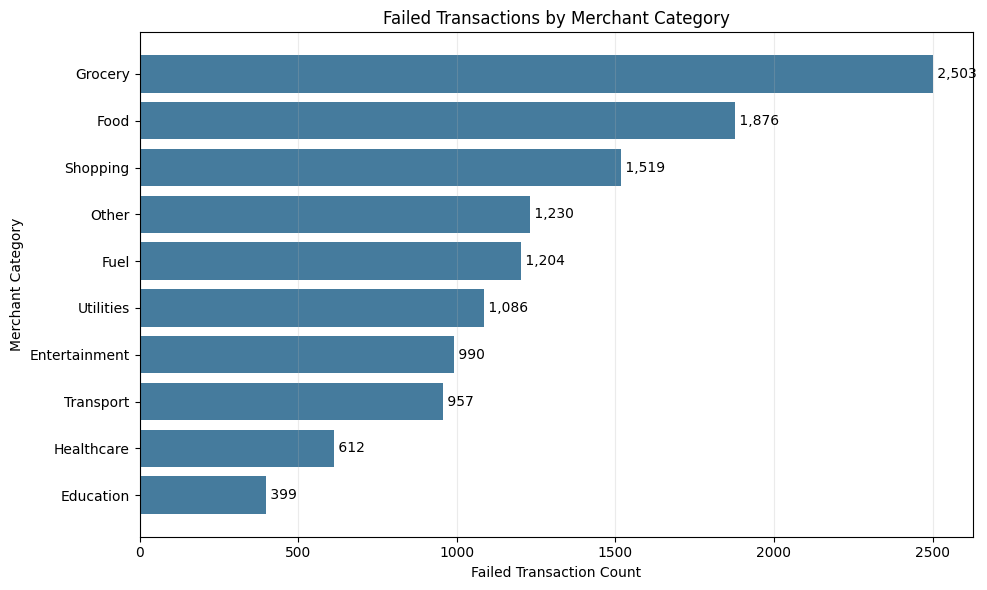

In [61]:
# Plot failed-transaction counts
fig, ax = plt.subplots(figsize=(10, 6))

count_order = merchant_status_summary.sort_values(
    "failed_transactions",
    ascending=True
)

bars = ax.barh(
    count_order["merchant_category"],
    count_order["failed_transactions"],
    color="#457B9D"
)

ax.set_title("Failed Transactions by Merchant Category")
ax.set_xlabel("Failed Transaction Count")
ax.set_ylabel("Merchant Category")
ax.grid(axis="x", alpha=0.25)

for bar, count in zip(
    bars,
    count_order["failed_transactions"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 6.3.3 Sender Bank vs Transaction Status
### Business Question
# Which sender banks have the highest number and rate of failed transactions?
### Objective
# To compare sender-bank transaction outcomes and identify banks with elevated failure rates or operational impact.

In [62]:
# Generate the summary using the existing function
sender_bank_status = build_status_summary(
    df,
    "sender_bank"
)

sender_bank_status

,sender_bank,total_transactions,successful_transactions,failed_transactions,success_rate_percentage,failure_rate_percentage
7,Yes Bank,24860,23591,1269,94.90,5.10
2,ICICI,29769,28270,1499,94.96,5.04
4,Kotak,20032,19034,998,95.02,4.98
0,Axis,25042,23803,1239,95.05,4.95
3,IndusInd,25173,23926,1247,95.05,4.95
6,SBI,62693,59598,3095,95.06,4.94
5,PNB,24946,23725,1221,95.11,4.89
1,HDFC,37485,35677,1808,95.18,4.82


In [63]:
# Verify totals
print(
    "Total transactions represented:",
    f"{sender_bank_status['total_transactions'].sum():,}"
)

print(
    "Total failures represented:",
    f"{sender_bank_status['failed_transactions'].sum():,}"
)

Total transactions represented: 250,000
Total failures represented: 12,376


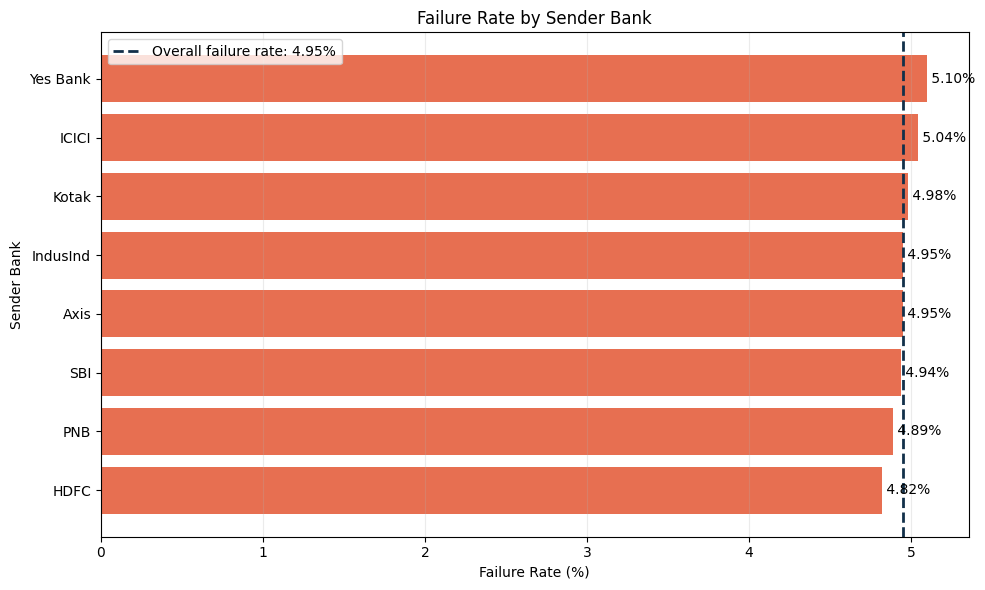

In [64]:
# Failure-rate chart
rate_order = sender_bank_status.sort_values(
    "failure_rate_percentage",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    rate_order["sender_bank"],
    rate_order["failure_rate_percentage"],
    color="#E76F51"
)

ax.axvline(
    overall_failure_rate,
    color="#12304A",
    linestyle="--",
    linewidth=2,
    label=f"Overall failure rate: {overall_failure_rate:.2f}%"
)

ax.set_title("Failure Rate by Sender Bank")
ax.set_xlabel("Failure Rate (%)")
ax.set_ylabel("Sender Bank")
ax.grid(axis="x", alpha=0.25)
ax.legend()

for bar, rate in zip(
    bars,
    rate_order["failure_rate_percentage"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {rate:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

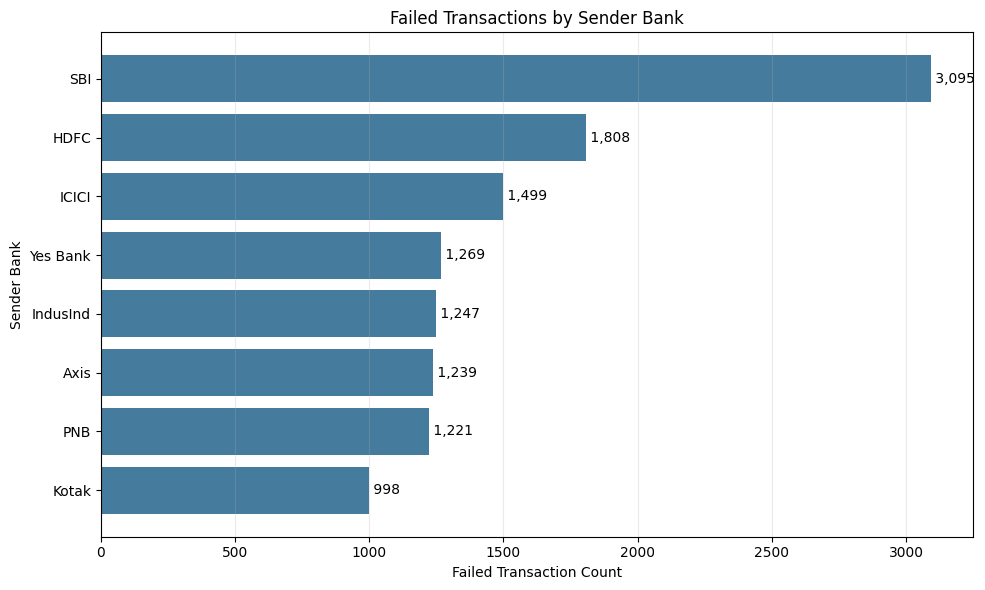

In [65]:
# Failed-count chart
count_order = sender_bank_status.sort_values(
    "failed_transactions",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    count_order["sender_bank"],
    count_order["failed_transactions"],
    color="#457B9D"
)

ax.set_title("Failed Transactions by Sender Bank")
ax.set_xlabel("Failed Transaction Count")
ax.set_ylabel("Sender Bank")
ax.grid(axis="x", alpha=0.25)

for bar, count in zip(
    bars,
    count_order["failed_transactions"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {count:,}",
        va="center"
    )

plt.tight_layout()
plt.show()